In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
sys.path.append('/Users/kevinlaventure/python_code')
from python_module.pricing_model import SABRModel

# Configure pandas display settings
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:_.4f}')


## SABR Monte Carlo Simulation

Simulates forward and stochastic volatility paths under the SABR model using
`SABRModel.compute_montecarlo` (Euler-Maruyama scheme) with standard parameters.

In [2]:
# Standard SABR parameters
F = 100.0      # Forward price
T = 1.0        # Time to maturity (years)
alpha = 0.20   # Initial volatility
beta = 1.0     # CEV exponent (1 = lognormal)
rho = -0.30    # Correlation between forward and volatility
nu = 0.40      # Vol of vol

n_steps = 252  # Daily steps over 1 year
n_paths = 10000

F_paths, sigma_paths = SABRModel.compute_montecarlo(
    F=F, T=T, alpha=alpha, beta=beta, rho=rho, nu=nu,
    n_steps=n_steps, n_paths=n_paths
)

F_paths.shape, sigma_paths.shape

((253, 10000), (253, 10000))

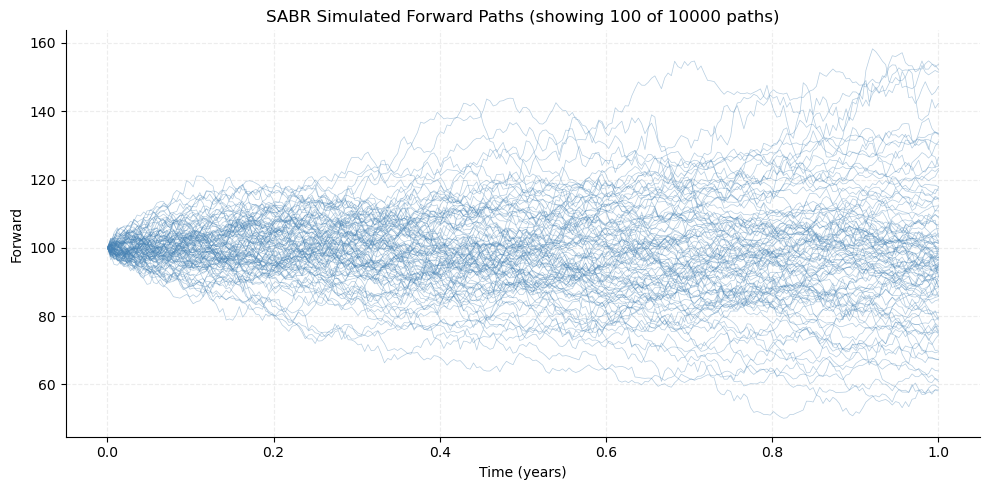

In [3]:
# Plot a sample of simulated forward paths
n_display = 100
time_grid = np.linspace(0, T, n_steps + 1)

fig, ax = plt.subplots(figsize=(10, 5))
for col in F_paths.columns[:n_display]:
    ax.plot(time_grid, F_paths[col], linewidth=0.5, alpha=0.4, color='steelblue')
ax.set_title(f'SABR Simulated Forward Paths (showing {n_display} of {n_paths} paths)')
ax.set_xlabel('Time (years)')
ax.set_ylabel('Forward')
ax.set_facecolor('white')
fig.patch.set_facecolor('white')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.4, color='lightgray')
plt.tight_layout()
plt.show()


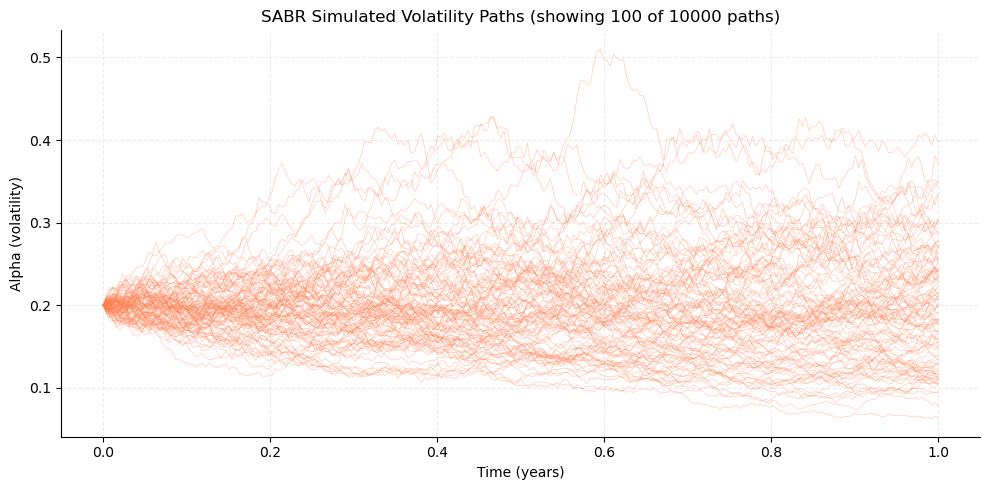

In [4]:
# Plot a sample of simulated volatility (alpha) paths
fig, ax = plt.subplots(figsize=(10, 5))
for col in sigma_paths.columns[:n_display]:
    ax.plot(time_grid, sigma_paths[col], linewidth=0.5, alpha=0.4, color='coral')
ax.set_title(f'SABR Simulated Volatility Paths (showing {n_display} of {n_paths} paths)')
ax.set_xlabel('Time (years)')
ax.set_ylabel('Alpha (volatility)')
ax.set_facecolor('white')
fig.patch.set_facecolor('white')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.4, color='lightgray')
plt.tight_layout()
plt.show()


In [5]:
# Terminal distribution summary
F_terminal = F_paths.iloc[-1, :]
sigma_terminal = sigma_paths.iloc[-1, :]

summary = pd.DataFrame({
    'forward': F_terminal.describe(),
    'volatility': sigma_terminal.describe()
})
summary

,forward,volatility
count,10_000.0000,10_000.0000
mean,99.6059,0.1995
std,20.3300,0.0827
min,30.6227,0.0362
25%,86.0659,0.1402
50%,98.6906,0.1847
75%,112.3126,0.2425
max,214.3936,0.8577


## Option Portfolio Revaluation Along the Simulation

Builds a portfolio of 100 options with strikes spanning 70% to 130% of the initial
forward (puts below F0, calls above F0), with maturity equal to the number of days
of the Monte Carlo simulation. At each simulation step, the portfolio is repriced
under the SABR model using the simulated forward and volatility, with time to
maturity decreasing accordingly.

In [6]:
from scipy import stats

# Option portfolio: 100 options with strikes between 70% and 130% of F0,
# maturity equal to the number of days of the Monte Carlo simulation
F0 = F
r = 0.0
n_options = 100
strikes = np.linspace(0.7 * F0, 1.3 * F0, n_options)
is_call = (strikes >= F0)[None, :]


def sabr_iv_vectorized(F_arr, K_arr, T, alpha_arr, beta, rho, nu):
    eps = 1e-8
    is_atm = np.abs(F_arr - K_arr) < eps
    F_safe = np.where(is_atm, F_arr + eps, F_arr)

    FK_beta = (F_safe * K_arr) ** ((1 - beta) / 2)
    log_FK = np.log(F_safe / K_arr)
    z = (nu / alpha_arr) * FK_beta * log_FK
    x_z = np.log((np.sqrt(1 - 2 * rho * z + z ** 2) + z - rho) / (1 - rho))

    factor1 = alpha_arr / (FK_beta * (1 + (1 - beta) ** 2 * log_FK ** 2 / 24 + (1 - beta) ** 4 * log_FK ** 4 / 1920))
    factor2 = np.where(np.abs(z) < eps, 1.0, z / np.where(np.abs(x_z) < eps, 1.0, x_z))
    factor3 = 1 + (
        ((1 - beta) ** 2 * alpha_arr ** 2) / (24 * (F_safe ** (2 - 2 * beta)))
        + 0.25 * rho * beta * nu * alpha_arr / (F_safe ** (1 - beta))
        + (2 - 3 * rho ** 2) * nu ** 2 / 24
    ) * T
    return factor1 * factor2 * factor3


def black76_vectorized(F_arr, K_arr, T, r, sigma_arr, is_call):
    sqrtT = np.sqrt(T)
    d1 = (np.log(F_arr / K_arr) + 0.5 * sigma_arr ** 2 * T) / (sigma_arr * sqrtT)
    d2 = d1 - sigma_arr * sqrtT
    discount = np.exp(-r * T)
    call_price = discount * (F_arr * stats.norm.cdf(d1) - K_arr * stats.norm.cdf(d2))
    put_price = discount * (K_arr * stats.norm.cdf(-d2) - F_arr * stats.norm.cdf(-d1))
    call_delta = discount * stats.norm.cdf(d1)
    put_delta = discount * (stats.norm.cdf(d1) - 1)
    price = np.where(is_call, call_price, put_price)
    delta = np.where(is_call, call_delta, put_delta)
    return price, delta


# Per-option price/delta for every step, path and option: shape (n_steps+1, n_paths, n_options)
price_array = np.zeros((n_steps + 1, n_paths, n_options), dtype=np.float32)
delta_array = np.zeros((n_steps + 1, n_paths, n_options), dtype=np.float32)

for t in range(n_steps + 1):
    T_remaining = T * (n_steps - t) / n_steps
    F_t = F_paths.iloc[t].values[:, None]
    alpha_t = sigma_paths.iloc[t].values[:, None]
    K_grid = strikes[None, :]

    if T_remaining > 0:
        iv = sabr_iv_vectorized(F_t, K_grid, T_remaining, alpha_t, beta, rho, nu)
        opt_price, opt_delta = black76_vectorized(F_t, K_grid, T_remaining, r, iv, is_call)
    else:
        opt_price = np.where(is_call, np.maximum(F_t - K_grid, 0.0), np.maximum(K_grid - F_t, 0.0))
        opt_delta = np.where(is_call, (F_t > K_grid).astype(float), -(F_t < K_grid).astype(float))

    price_array[t] = opt_price
    delta_array[t] = opt_delta

forward_timeseries = F_paths
alpha_timeseries = sigma_paths
option_price_timeseries = pd.DataFrame(price_array.sum(axis=2), index=F_paths.index, columns=F_paths.columns)
option_delta_timeseries = pd.DataFrame(delta_array.sum(axis=2), index=F_paths.index, columns=F_paths.columns)

forward_timeseries.shape, alpha_timeseries.shape, option_price_timeseries.shape, option_delta_timeseries.shape

((253, 10000), (253, 10000), (253, 10000), (253, 10000))

## Per-Path Option Price/Delta Breakdown

Reshapes the per-option price and delta arrays into a dict keyed by path number,
where each entry is a DataFrame indexed by day (in line with the Monte Carlo
simulation) with one column per option (1 to 100).

In [7]:
option_columns = np.arange(1, n_options + 1)

option_price_timeseries_dict = {
    path: pd.DataFrame(price_array[:, path, :], index=forward_timeseries.index, columns=option_columns)
    for path in range(n_paths)
}
option_delta_timeseries_dict = {
    path: pd.DataFrame(delta_array[:, path, :], index=forward_timeseries.index, columns=option_columns)
    for path in range(n_paths)
}

len(option_price_timeseries_dict), len(option_delta_timeseries_dict), option_price_timeseries_dict[0].shape

(10000, 10000, (253, 100))

In [8]:
# Mapping between option number (columns of option_price_timeseries_dict) and strike
option_strike_map = pd.Series(strikes, index=option_price_timeseries_dict[0].columns, name='strike')

In [9]:
spot_grid = np.linspace(F0 * 0.6, F0 * 1.4, 200)
is_call_1d = (strikes >= F0)

F_terminal_grid = spot_grid[:, None]
K_grid_2d = strikes[None, :]

intrinsic_call = np.maximum(F_terminal_grid - K_grid_2d, 0.0)
intrinsic_put = np.maximum(K_grid_2d - F_terminal_grid, 0.0)

terminal_payoff = pd.DataFrame(
    np.where(is_call_1d[None, :], intrinsic_call, intrinsic_put),
    index=spot_grid,
    columns=option_columns
)
terminal_payoff.index.name = 'terminal_forward'
terminal_payoff

,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100
terminal_forward,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
60.0000,10.0000,10.6061,11.2121,11.8182,12.4242,13.0303,13.6364,14.2424,14.8485,15.4545,16.0606,16.6667,17.2727,17.8788,18.4848,19.0909,19.6970,20.3030,20.9091,21.5152,22.1212,22.7273,23.3333,23.9394,24.5455,25.1515,25.7576,26.3636,26.9697,27.5758,28.1818,28.7879,29.3939,30.0000,30.6061,31.2121,31.8182,32.4242,33.0303,33.6364,34.2424,34.8485,35.4545,36.0606,36.6667,37.2727,37.8788,38.4848,39.0909,39.6970,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
60.4020,9.5980,10.2041,10.8101,11.4162,12.0222,12.6283,13.2344,13.8404,14.4465,15.0525,15.6586,16.2647,16.8707,17.4768,18.0828,18.6889,19.2950,19.9010,20.5071,21.1131,21.7192,22.3253,22.9313,23.5374,24.1434,24.7495,25.3556,25.9616,26.5677,27.1737,27.7798,28.3859,28.9919,29.5980,30.2041,30.8101,31.4162,32.0222,32.6283,33.2344,33.8404,34.4465,35.0525,35.6586,36.2647,36.8707,37.4768,38.0828,38.6889,39.2950,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
60.8040,9.1960,9.8020,10.4081,11.0142,11.6202,12.2263,12.8323,13.4384,14.0445,14.6505,15.2566,15.8626,16.4687,17.0748,17.6808,18.2869,18.8929,19.4990,20.1051,20.7111,21.3172,21.9233,22.5293,23.1354,23.7414,24.3475,24.9536,25.5596,26.1657,26.7717,27.3778,27.9839,28.5899,29.1960,29.8020,30.4081,31.0142,31.6202,32.2263,32.8323,33.4384,34.0445,34.6505,35.2566,35.8626,36.4687,37.0748,37.6808,38.2869,38.8929,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
61.2060,8.7940,9.4000,10.0061,10.6122,11.2182,11.8243,12.4303,13.0364,13.6425,14.2485,14.8546,15.4606,16.0667,16.6728,17.2788,17.8849,18.4909,19.0970,19.7031,20.3091,20.9152,21.5212,22.1273,22.7334,23.3394,23.9455,24.5515,25.1576,25.7637,26.3697,26.9758,27.5818,28.1879,28.7940,29.4000,30.0061,30.6122,31.2182,31.8243,32.4303,33.0364,33.6425,34.2485,34.8546,35.4606,36.0667,36.6728,37.2788,37.8849,38.4909,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
61.6080,8.3920,8.9980,9.6041,10.2101,10.8162,11.4223,12.0283,12.6344,13.2404,13.8465,14.4526,15.0586,15.6647,16.2707,16.8768,17.4829,18.0889,18.6950,19.3011,19.9071,20.5132,21.1192,21.7253,22.3314,22.9374,23.5435,24.1495,24.7556,25.3617,25.9677,26.5738,27.1798,27.7859,28.3920,28.9980,29.6041,30.2101,30.8162,31.4223,32.0283,32.6344,33.2404,33.8465,34.4526,35.0586,35.6647,36.2707,36.8768,37.4829,38.0889,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.00

In [10]:
from sklearn.linear_model import lars_path

X = terminal_payoff.values                          # (200, 100)
y = terminal_payoff.dot(np.ones(n_options)).values  # full portfolio payoff, weight=1 per option

# Lasso regularisation path via LARS — traces sparsity from 0 to all 100 options
alphas, _, coefs = lars_path(X, y, method='lasso', verbose=False)

# Pick the step where exactly 20 options become active
n_active = (coefs != 0).sum(axis=0)
idx_20 = int(np.argmax(n_active >= 20))

lasso_weights = pd.Series(coefs[:, idx_20], index=option_columns, name='lasso_weight')
lasso_selected = lasso_weights[lasso_weights != 0].rename('weight').to_frame()
lasso_selected['strike'] = option_strike_map[lasso_selected.index].values
lasso_selected['option_type'] = np.where(lasso_selected['strike'] >= F0, 'call', 'put')

portfolio_full_payoff = pd.Series(y, index=terminal_payoff.index, name='full_portfolio')
portfolio_lasso_payoff = pd.Series(X @ lasso_weights.values, index=terminal_payoff.index, name='lasso_20_options')

residuals = portfolio_full_payoff - portfolio_lasso_payoff
print(f"Active options : {len(lasso_selected)} / {n_options}")
print(f"R²             : {1 - residuals.var() / portfolio_full_payoff.var():.6f}")
print(f"Max abs error  : {residuals.abs().max():.4f}")
print()
lasso_selected

Active options : 20 / 100
R²             : 0.939028
Max abs error  : 246.7572



,weight,strike,option_type
40,15.8667,93.6364,put
41,4.4809,94.2424,put
43,1.2897,95.4545,put
44,0.9158,96.0606,put
45,1.0245,96.6667,put
46,0.9928,97.2727,put
47,1.0021,97.8788,put
48,0.9994,98.4848,put
49,1.0002,99.0909,put
50,1.0000,99.6970,put


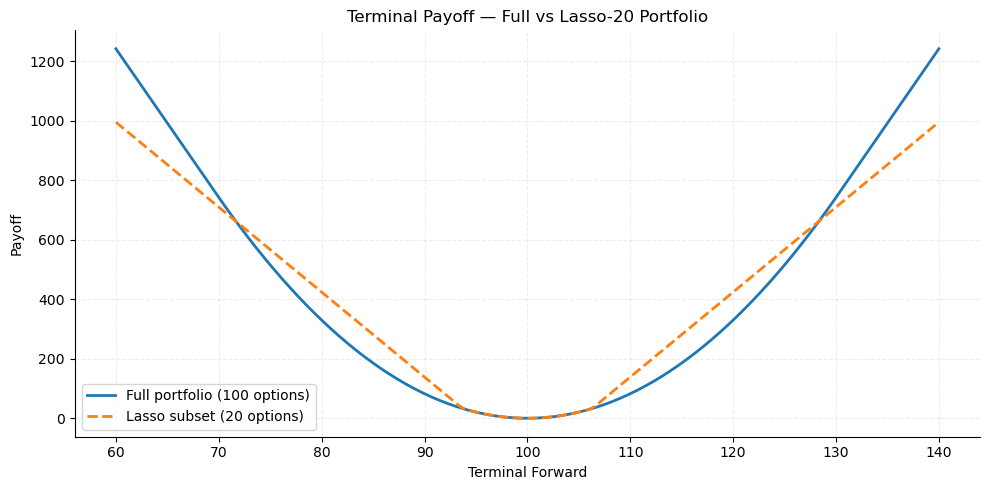

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(portfolio_full_payoff.index, portfolio_full_payoff.values, linewidth=2, label='Full portfolio (100 options)')
ax.plot(portfolio_lasso_payoff.index, portfolio_lasso_payoff.values, linewidth=2, linestyle='--', label='Lasso subset (20 options)')
ax.set_title('Terminal Payoff — Full vs Lasso-20 Portfolio')
ax.set_xlabel('Terminal Forward')
ax.set_ylabel('Payoff')
ax.legend()
ax.set_facecolor('white')
fig.patch.set_facecolor('white')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.4, color='lightgray')
plt.tight_layout()
plt.show()


In [12]:
# Lasso-weighted portfolio price at each MC step: price_array (253, 10000, 100) @ weights (100,) -> (253, 10000)
option_price_timeseries_opt = pd.DataFrame(
    price_array @ lasso_weights.values,
    index=forward_timeseries.index,
    columns=forward_timeseries.columns
)
option_price_timeseries_opt.shape

(253, 10000)

In [13]:
spread_pnl = option_price_timeseries_opt.iloc[-1]-option_price_timeseries.iloc[-1]
spread_pnl = spread_pnl.to_frame(name='spread_pnl')
spread_pnl['forward_price'] = spread_pnl.index.map(forward_timeseries.iloc[-1])

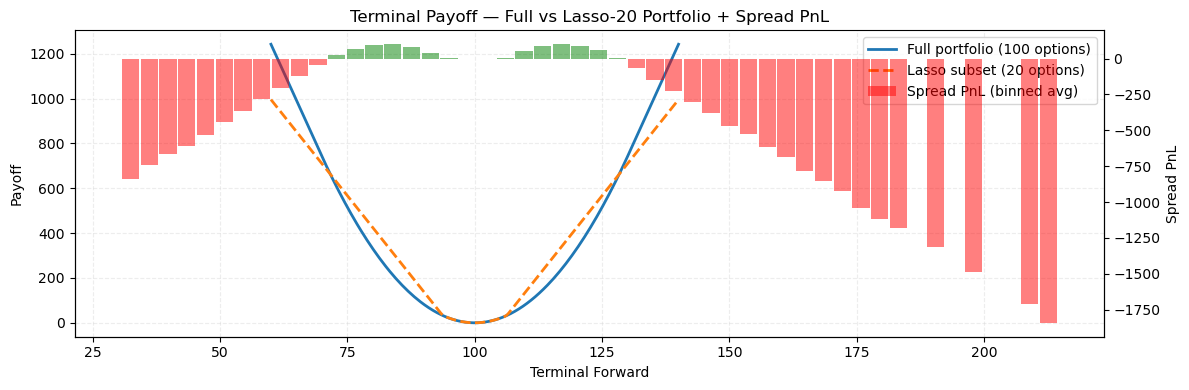

In [25]:
df_sorted = spread_pnl.sort_values('forward_price')
bins = pd.cut(df_sorted['forward_price'], bins=50)
binned = df_sorted.groupby(bins, observed=True)['spread_pnl'].mean()
bin_centers = binned.index.map(lambda i: i.mid)
colors = ['green' if v >= 0 else 'red' for v in binned.values]

fig, ax1 = plt.subplots(figsize=(12, 4))
ax2 = ax1.twinx()
ax1.plot(portfolio_full_payoff.index, portfolio_full_payoff.values, linewidth=2, label='Full portfolio (100 options)', color='#1f77b4')
ax1.plot(portfolio_lasso_payoff.index, portfolio_lasso_payoff.values, linewidth=2, linestyle='--', label='Lasso subset (20 options)', color='#ff7f0e')
bin_width = float(bin_centers.values[1] - bin_centers.values[0]) * 0.9
ax2.bar(bin_centers.values.astype(float), binned.values, width=bin_width, color=colors, alpha=0.5, label='Spread PnL (binned avg)')
ax1.set_title('Terminal Payoff — Full vs Lasso-20 Portfolio + Spread PnL')
ax1.set_xlabel('Terminal Forward')
ax1.set_ylabel('Payoff')
ax2.set_ylabel('Spread PnL')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
ax1.set_facecolor('white')
fig.patch.set_facecolor('white')
ax1.spines[['top']].set_visible(False)
ax1.grid(True, linestyle='--', alpha=0.4, color='lightgray')
plt.tight_layout()
plt.show()


In [15]:
# Lasso-weighted delta timeseries: delta_array (253, 10000, 100) @ weights (100,) -> (253, 10000)
option_delta_timeseries_opt = pd.DataFrame(
    delta_array @ lasso_weights.values,
    index=forward_timeseries.index,
    columns=forward_timeseries.columns
)

# Delta hedging PnL per step: (F_t - F_{t-1}) * delta_{t-1}
dF = forward_timeseries.diff()

delta_hedge_pnl_full = (dF * option_delta_timeseries.shift(1)).dropna()
delta_hedge_pnl_opt  = (dF * option_delta_timeseries_opt.shift(1)).dropna()

delta_hedge_pnl_full.shape, delta_hedge_pnl_opt.shape

((252, 10000), (252, 10000))

In [16]:
spread_pnl['dh'] = spread_pnl.index.map((delta_hedge_pnl_full-delta_hedge_pnl_opt).sum())
spread_pnl['dh_spread_pnl'] = spread_pnl['spread_pnl'] + spread_pnl['dh']

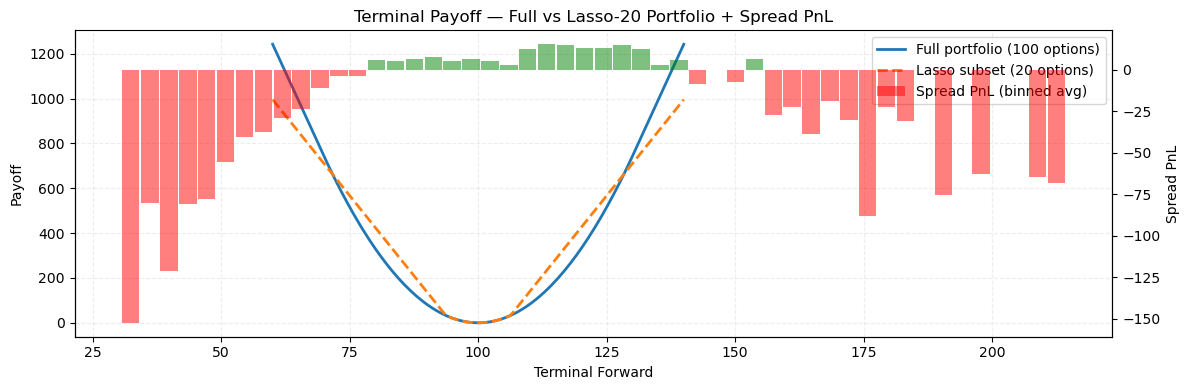

In [24]:
df_sorted = spread_pnl.sort_values('forward_price')
bins = pd.cut(df_sorted['forward_price'], bins=50)
binned = df_sorted.groupby(bins, observed=True)['dh_spread_pnl'].mean()
bin_centers = binned.index.map(lambda i: i.mid)
colors = ['green' if v >= 0 else 'red' for v in binned.values]

fig, ax1 = plt.subplots(figsize=(12, 4))
ax2 = ax1.twinx()
ax1.plot(portfolio_full_payoff.index, portfolio_full_payoff.values, linewidth=2, label='Full portfolio (100 options)', color='#1f77b4')
ax1.plot(portfolio_lasso_payoff.index, portfolio_lasso_payoff.values, linewidth=2, linestyle='--', label='Lasso subset (20 options)', color='#ff7f0e')
bin_width = float(bin_centers.values[1] - bin_centers.values[0]) * 0.9
ax2.bar(bin_centers.values.astype(float), binned.values, width=bin_width, color=colors, alpha=0.5, label='Spread PnL (binned avg)')
ax1.set_title('Terminal Payoff — Full vs Lasso-20 Portfolio + Spread PnL')
ax1.set_xlabel('Terminal Forward')
ax1.set_ylabel('Payoff')
ax2.set_ylabel('Spread PnL')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
ax1.set_facecolor('white')
fig.patch.set_facecolor('white')
ax1.spines[['top']].set_visible(False)
ax1.grid(True, linestyle='--', alpha=0.4, color='lightgray')
plt.tight_layout()
plt.show()


In [18]:
spread_pnl[['spread_pnl', 'dh_spread_pnl']].describe()

,spread_pnl,dh_spread_pnl
count,10_000.0000,10_000.0000
mean,6.2700,4.1929
std,131.7485,38.4076
min,-1_840.8608,-346.7351
25%,-0.0000,-10.8155
50%,28.5816,12.7655
75%,82.4860,27.9906
max,100.2397,109.0773
